In [1]:
!pip install pandas numpy matplotlib seaborn pyarrow


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_pref = pd.read_parquet("Preference-dissection.parquet")

print(df_pref.shape)
print(df_pref.columns.tolist())
df_pref.head()

(5240, 18)
['query', 'scenario_auto-j', 'scenario_group', 'response_1', 'response_2', 'gpt-4-turbo_reference', 'clear intent', 'explicitly express feelings', 'explicit constraints', 'explicit subjective stances', 'explicit mistakes or biases', 'preference_labels', 'basic_response_1', 'basic_response_2', 'errors_response_1', 'errors_response_2', 'query-specific_response_1', 'query-specific_response_2']


,query,scenario_auto-j,scenario_group,response_1,response_2,gpt-4-turbo_reference,clear intent,explicitly express feelings,explicit constraints,explicit subjective stances,explicit mistakes or biases,preference_labels,basic_response_1,basic_response_2,errors_response_1,errors_response_2,query-specific_response_1,query-specific_response_2
0,Generate a list of steps needed to book a flig...,functional_writing,Functional Writing,{'content': '1. Go to a travel agent or websit...,{'content': '1. Choose your destination and tr...,1. Choose your destination and dates of travel...,Yes,No,[Be concise],[],[],"{'gpt-3.5-turbo-1106': 'response_2', 'gpt-4-11...","{'admit limitations or mistakes': 0, 'authorit...","{'admit limitations or mistakes': 0, 'authorit...","{'applicable or not': 'applicable', 'errors': ...","{'applicable or not': 'applicable', 'errors': []}","{'clarify user intent': None, 'correcting expl...","{'clarify user intent': None, 'correcting expl..."
1,Tell you some rules. When identifying input el...,default,Others,{'content': 'Thank you for the clarification. ...,{'content': 'Got it. Thanks for the clarificat...,It seems you're describing a specific scenario...,No,No,[],[],[],"{'gpt-3.5-turbo-1106': 'response_1', 'gpt-4-11...","{'admit limitations or mistakes': 0, 'authorit...","{'admit limitations or mistakes': 0, 'authorit...","{'applicable or not': 'applicable', 'errors': ...","{'applicable or not': 'applicable', 'errors': ...","{'clarify user intent': 2.0, 'correcting expli...","{'clarify user intent': 0.0, 'correcting expli..."
2,explain to me very shortly what is the CIE RGB...,explaining_general,Knowledge-aware,{'content': 'The CIE RGB XYZ color space is a ...,"{'content': 'OK, the CIE XYZ color model is a ...",The CIE RGB and XYZ conventions are color spac...,Yes,No,[explain very shortly],[],[],"{'gpt-3.5-turbo-1106': 'response_1', 'gpt-4-11...","{'admit limitations or mistakes': 0, 'authorit...","{'admit limitations or mistakes': 0, 'authorit...","{'applicable or not': 'applicable', 'errors': ...","{'applicable or not': 'applicable', 'errors': ...","{'clarify user intent': None, 'correcting expl...","{'clarify user intent': None, 'correcting expl..."
3,Please create a task for student to write prog...,default,Others,{'content': 'Here is a suggested task for the ...,"{'content': 'Task: As a programming student, ...",Certainly! Below is a task description for a s...,Yes,No,"[The task must involve writing a program, The ...",[],[],"{'gpt-3.5-turbo-1106': 'response_2', 'gpt-4-11...","{'admit limitations or mistakes': 0, 'authorit...","{'admit limitations or mistakes': 0, 'authorit...","{'applicable or not': 'applicable', 'errors': ...","{'applicable or not': 'applicable', 'errors': ...","{'clarify user intent': None, 'correcting expl...","{'clarify user intent': None, 'correcting expl..."
4,"Write a python program to read a csv file, get...",code_generation,Code,{'content': '``` import csv # Open the CSV fi...,{'content': 'Here's a Python program that read...,"To read a CSV file, get the headers, and displ...",Yes,No,[],[],[],"{'gpt-3.5-turbo-1106': 'response_2', 'gpt-4-11...","{'admit limitations or mistakes': 0, 'authorit...","{'admit limitations or mistakes': 0, 'authorit...","{'applicable or not': 'applicable', 'errors': ...","{'applicable or not': 'applicable', 'errors': ...","{'clarify user intent': None, 'correcting expl...","{'clarify user intent': None, 'correcting expl..."


In [4]:
for col in ["query", "response_1", "response_2"]:
    print(col, "=>", col in df_pref.columns)

query => True
response_1 => True
response_2 => True


In [5]:
def extract_response_text(x):
    if isinstance(x, dict):
        return x.get("content", "")
    return str(x)

df_pref["response_1_text"] = df_pref["response_1"].apply(extract_response_text)
df_pref["response_2_text"] = df_pref["response_2"].apply(extract_response_text)

df_pref[["query", "response_1_text", "response_2_text"]].head()

,query,response_1_text,response_2_text
0,Generate a list of steps needed to book a flig...,1. Go to a travel agent or website that specia...,1. Choose your destination and travel dates.\n...
1,Tell you some rules. When identifying input el...,Thank you for the clarification. Based on your...,Got it. Thanks for the clarification.
2,explain to me very shortly what is the CIE RGB...,The CIE RGB XYZ color space is a way of repres...,"OK, the CIE XYZ color model is a standard way ..."
3,Please create a task for student to write prog...,Here is a suggested task for the student:\n\nT...,"Task:\n\nAs a programming student, you are tas..."
4,"Write a python program to read a csv file, get...",```\nimport csv\n\n# Open the CSV file\nfile =...,"Here's a Python program that reads a CSV file,..."


In [6]:
df_eval_pref = pd.DataFrame({
    "dataset": "preference_dissection",
    "record_id": df_pref.index,
    "query": df_pref["query"],
    "response_1": df_pref["response_1_text"],
    "response_2": df_pref["response_2_text"],

    # Response 1 scores
    "r1_accuracy": np.nan,
    "r1_relevance": np.nan,
    "r1_completeness": np.nan,
    "r1_consistency": np.nan,
    "r1_clarity": np.nan,
    "r1_reasoning_quality": np.nan,

    # Response 2 scores
    "r2_accuracy": np.nan,
    "r2_relevance": np.nan,
    "r2_completeness": np.nan,
    "r2_consistency": np.nan,
    "r2_clarity": np.nan,
    "r2_reasoning_quality": np.nan,

    # Preference judgement
    "preferred_response": "",
    "preference_type": "",   # factual / logical / completeness / tie
    "weaker_response": "",
    "weaker_response_errors": "",
    "preference_justification": "",
    "improvement_recommendation": ""
})

df_eval_pref.head()

,dataset,record_id,query,response_1,response_2,r1_accuracy,r1_relevance,r1_completeness,r1_consistency,r1_clarity,...,r2_completeness,r2_consistency,r2_clarity,r2_reasoning_quality,preferred_response,preference_type,weaker_response,weaker_response_errors,preference_justification,improvement_recommendation
0,preference_dissection,0,Generate a list of steps needed to book a flig...,1. Go to a travel agent or website that specia...,1. Choose your destination and travel dates.\n...,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,,,,,,
1,preference_dissection,1,Tell you some rules. When identifying input el...,Thank you for the clarification. Based on your...,Got it. Thanks for the clarification.,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,,,,,,
2,preference_dissection,2,explain to me very shortly what is the CIE RGB...,The CIE RGB XYZ color space is a way of repres...,"OK, the CIE XYZ color model is a standard way ...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,,,,,,
3,preference_dissection,3,Please create a task for student to write prog...,Here is a suggested task for the student:\n\nT...,"Task:\n\nAs a programming student, you are tas...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,,,,,,
4,preference_dissection,4,"Write a python program to read a csv file, get...",```\nimport csv\n\n# Open the CSV file\nfile =...,"Here's a Python program that reads a CSV file,...",NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,,,,,,


In [7]:
row_id = 0

# Response 1
df_eval_pref.loc[row_id, "r1_accuracy"] = 4
df_eval_pref.loc[row_id, "r1_relevance"] = 5
df_eval_pref.loc[row_id, "r1_completeness"] = 4
df_eval_pref.loc[row_id, "r1_consistency"] = 4
df_eval_pref.loc[row_id, "r1_clarity"] = 4
df_eval_pref.loc[row_id, "r1_reasoning_quality"] = 4

# Response 2
df_eval_pref.loc[row_id, "r2_accuracy"] = 3
df_eval_pref.loc[row_id, "r2_relevance"] = 4
df_eval_pref.loc[row_id, "r2_completeness"] = 3
df_eval_pref.loc[row_id, "r2_consistency"] = 4
df_eval_pref.loc[row_id, "r2_clarity"] = 4
df_eval_pref.loc[row_id, "r2_reasoning_quality"] = 3

In [8]:
r1_cols = ["r1_accuracy", "r1_relevance", "r1_completeness", "r1_consistency", "r1_clarity", "r1_reasoning_quality"]
r2_cols = ["r2_accuracy", "r2_relevance", "r2_completeness", "r2_consistency", "r2_clarity", "r2_reasoning_quality"]

df_eval_pref["r1_total"] = df_eval_pref[r1_cols].mean(axis=1)
df_eval_pref["r2_total"] = df_eval_pref[r2_cols].mean(axis=1)

def choose_preference(row):
    if row["r1_total"] > row["r2_total"]:
        return "response_1"
    elif row["r2_total"] > row["r1_total"]:
        return "response_2"
    return "tie"

df_eval_pref["preferred_response"] = df_eval_pref.apply(choose_preference, axis=1)

In [9]:
df_eval_pref.loc[row_id, "preference_type"] = "completeness_related"
df_eval_pref.loc[row_id, "weaker_response"] = "response_2"
df_eval_pref.loc[row_id, "weaker_response_errors"] = "missing_key_step_or_omission; weaker_reasoning"
df_eval_pref.loc[row_id, "preference_justification"] = (
    "Response 1 is stronger because it more directly answers the query, includes more complete task guidance, "
    "and uses clearer reasoning. Response 2 is partially relevant but omits a key element of the answer."
)
df_eval_pref.loc[row_id, "improvement_recommendation"] = (
    "Make Response 2 more complete by addressing the missing step and improving logical explanation."
)

In [10]:
df_eval_pref["score_gap"] = (df_eval_pref["r1_total"] - df_eval_pref["r2_total"]).abs()

close_cases = df_eval_pref[df_eval_pref["score_gap"] <= 0.3]
print("Close / ambiguous comparisons:", len(close_cases))
close_cases[["query", "r1_total", "r2_total", "preferred_response"]].head()

Close / ambiguous comparisons: 0


,query,r1_total,r2_total,preferred_response


In [11]:
df_eval_pref = df_eval_pref.head(100).copy()

In [12]:
def score_relevance(query, response):
    overlap = sum(word in str(response).lower() for word in str(query).lower().split())
    return 4 if overlap >= 2 else 3

def score_clarity(response):
    words = str(response).split()
    if len(words) < 20:
        return 2
    elif len(words) <= 120:
        return 4
    return 3

def score_completeness(response):
    if any(word in str(response).lower() for word in ["step", "first", "then", "finally"]):
        return 4
    return 3

In [13]:
for prefix, resp_col in [("r1", "response_1"), ("r2", "response_2")]:
    df_eval_pref[f"{prefix}_relevance"] = df_eval_pref.apply(
        lambda x: score_relevance(x["query"], x[resp_col]), axis=1
    )
    df_eval_pref[f"{prefix}_clarity"] = df_eval_pref[resp_col].apply(score_clarity)
    df_eval_pref[f"{prefix}_completeness"] = df_eval_pref[resp_col].apply(score_completeness)
    
    # Neutral defaults
    df_eval_pref[f"{prefix}_accuracy"] = 4
    df_eval_pref[f"{prefix}_consistency"] = 4
    df_eval_pref[f"{prefix}_reasoning_quality"] = 3

In [14]:
preference_counts = (
    df_eval_pref["preferred_response"]
    .value_counts()
    .reset_index()
)
preference_counts.columns = ["preferred_response", "count"]
preference_counts

,preferred_response,count
0,tie,99
1,response_1,1


In [15]:
dimension_gaps = pd.DataFrame({
    "dimension": ["accuracy", "relevance", "completeness", "consistency", "clarity", "reasoning_quality"],
    "avg_gap": [
        (df_eval_pref["r1_accuracy"] - df_eval_pref["r2_accuracy"]).abs().mean(),
        (df_eval_pref["r1_relevance"] - df_eval_pref["r2_relevance"]).abs().mean(),
        (df_eval_pref["r1_completeness"] - df_eval_pref["r2_completeness"]).abs().mean(),
        (df_eval_pref["r1_consistency"] - df_eval_pref["r2_consistency"]).abs().mean(),
        (df_eval_pref["r1_clarity"] - df_eval_pref["r2_clarity"]).abs().mean(),
        (df_eval_pref["r1_reasoning_quality"] - df_eval_pref["r2_reasoning_quality"]).abs().mean()
    ]
}).sort_values("avg_gap", ascending=False)

dimension_gaps

,dimension,avg_gap
4,clarity,0.46
2,completeness,0.32
1,relevance,0.01
0,accuracy,0.00
3,consistency,0.00
5,reasoning_quality,0.00


In [16]:
from collections import Counter

error_list_pref = []

for entry in df_eval_pref["weaker_response_errors"].dropna():
    entry = str(entry).strip()
    if entry != "":
        error_list_pref.extend([err.strip() for err in entry.split(";") if err.strip() != ""])

error_counts_pref = pd.DataFrame(
    Counter(error_list_pref).items(),
    columns=["error_type", "count"]
).sort_values("count", ascending=False)

error_counts_pref

,error_type,count
0,missing_key_step_or_omission,1
1,weaker_reasoning,1


In [17]:
tie_rate = (df_eval_pref["preferred_response"] == "tie").mean() * 100
print(f"Tie rate: {tie_rate:.2f}%")

close_rate = (df_eval_pref["score_gap"] <= 0.3).mean() * 100
print(f"Close-decision rate: {close_rate:.2f}%")

Tie rate: 99.00%
Close-decision rate: 0.00%


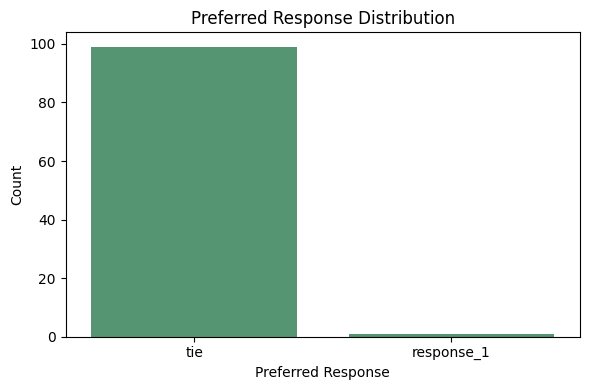

In [18]:
plt.figure(figsize=(6,4))
sns.barplot(data=preference_counts, x="preferred_response", y="count", color="#4C9F70")
plt.title("Preferred Response Distribution")
plt.xlabel("Preferred Response")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("pref_preferred_response_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

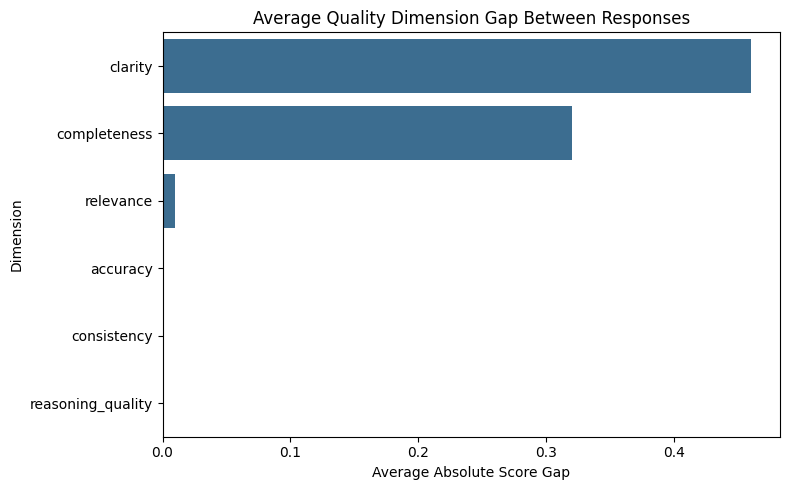

In [19]:
plt.figure(figsize=(8,5))
sns.barplot(data=dimension_gaps, x="avg_gap", y="dimension", color="#2E6F9E")
plt.title("Average Quality Dimension Gap Between Responses")
plt.xlabel("Average Absolute Score Gap")
plt.ylabel("Dimension")
plt.tight_layout()
plt.savefig("pref_dimension_gap_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

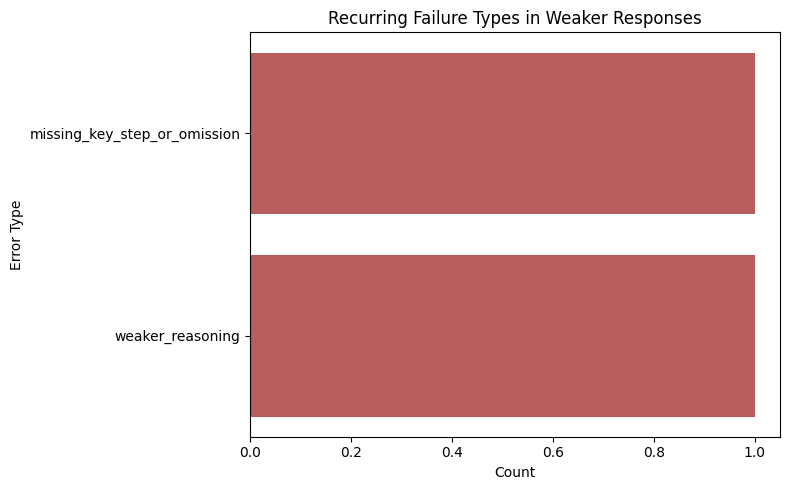

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(data=error_counts_pref, x="count", y="error_type", color="#C94C4C")
plt.title("Recurring Failure Types in Weaker Responses")
plt.xlabel("Count")
plt.ylabel("Error Type")
plt.tight_layout()
plt.savefig("pref_weaker_response_error_taxonomy.png", dpi=300, bbox_inches="tight")
plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

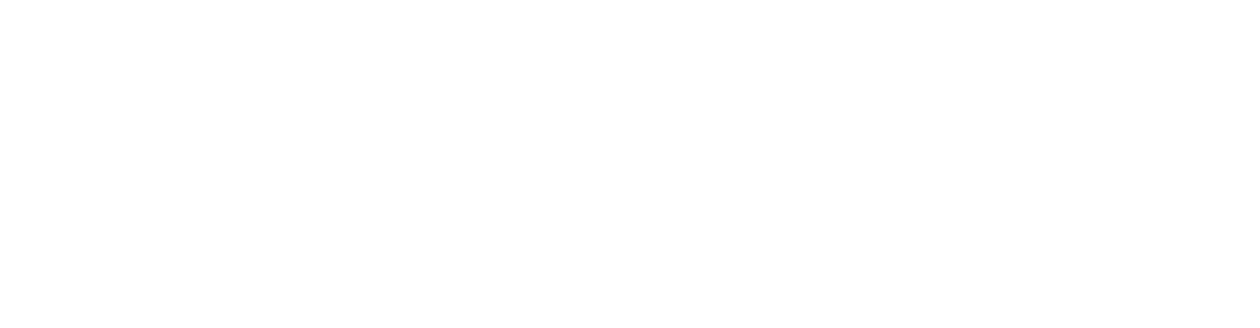

In [21]:
close_cases_display = close_cases[[
    "query", "response_1", "response_2", "r1_total", "r2_total", "preferred_response"
]].head(10)

close_cases_display.to_csv("pref_close_cases_examples.csv", index=False)

fig, ax = plt.subplots(figsize=(16, 4))
ax.axis('off')
tbl = ax.table(
    cellText=close_cases_display.values,
    colLabels=close_cases_display.columns,
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.5)
plt.tight_layout()
plt.savefig("pref_close_cases_examples_table.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
print("Number of close cases:", len(close_cases))
close_cases.head()

Number of close cases: 0


,dataset,record_id,query,response_1,response_2,r1_accuracy,r1_relevance,r1_completeness,r1_consistency,r1_clarity,...,r2_reasoning_quality,preferred_response,preference_type,weaker_response,weaker_response_errors,preference_justification,improvement_recommendation,r1_total,r2_total,score_gap


In [23]:
close_cases = df_eval_pref[df_eval_pref["score_gap"] <= 0.3]

In [24]:
print("Number of close cases:", len(close_cases))
close_cases.head()

Number of close cases: 0


,dataset,record_id,query,response_1,response_2,r1_accuracy,r1_relevance,r1_completeness,r1_consistency,r1_clarity,...,r2_reasoning_quality,preferred_response,preference_type,weaker_response,weaker_response_errors,preference_justification,improvement_recommendation,r1_total,r2_total,score_gap


In [25]:
close_cases = df_eval_pref[df_eval_pref["score_gap"] <= 0.5]

In [26]:
print("Number of close cases:", len(close_cases))
close_cases.head()

Number of close cases: 0


,dataset,record_id,query,response_1,response_2,r1_accuracy,r1_relevance,r1_completeness,r1_consistency,r1_clarity,...,r2_reasoning_quality,preferred_response,preference_type,weaker_response,weaker_response_errors,preference_justification,improvement_recommendation,r1_total,r2_total,score_gap


In [27]:
close_cases = df_eval_pref[df_eval_pref["score_gap"] <= 1.0]

In [28]:
print("Number of close cases:", len(close_cases))

Number of close cases: 1


                                               query  score_gap  \
0  Generate a list of steps needed to book a flig...   0.666667   
1  Tell you some rules. When identifying input el...        NaN   
2  explain to me very shortly what is the CIE RGB...        NaN   
3  Please create a task for student to write prog...        NaN   
4  Write a python program to read a csv file, get...        NaN   
5  Can you help me reset my password for my compu...        NaN   
6  what are some types of magical potions you mig...        NaN   
7        How should we cook apples for main dishes ?        NaN   
8  Give me a short history on the city of Toulous...        NaN   
9              Is Greek yoghurt bad for cholesterol         NaN   

  preferred_response  
0         response_1  
1                tie  
2                tie  
3                tie  
4                tie  
5                tie  
6                tie  
7                tie  
8                tie  
9                tie  


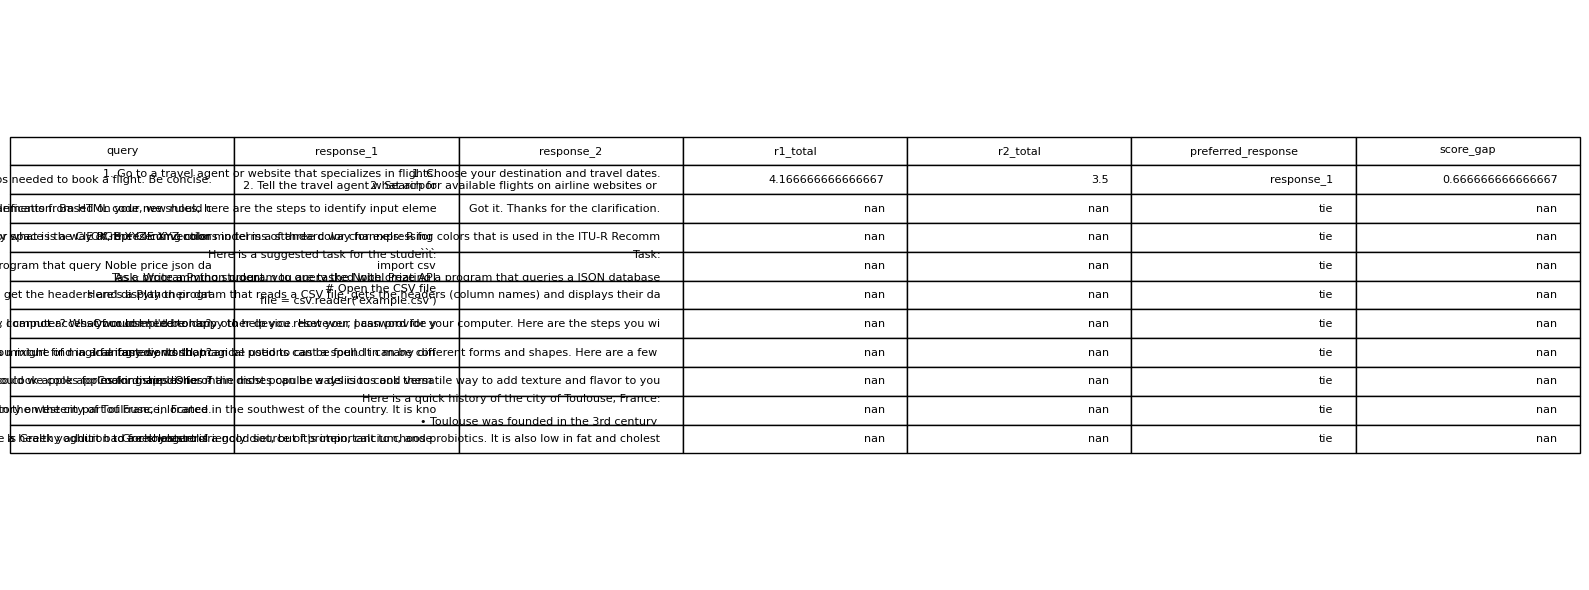

In [29]:
# Sort by smallest gap and take top 10 closest cases
closest_cases = df_eval_pref.sort_values("score_gap").head(10).copy()

print(closest_cases[["query", "score_gap", "preferred_response"]])

closest_cases_display = closest_cases[[
    "query", "response_1", "response_2", "r1_total", "r2_total", "preferred_response", "score_gap"
]].copy()

# Shorten text for rendering
closest_cases_display["query"] = closest_cases_display["query"].astype(str).str.slice(0, 80)
closest_cases_display["response_1"] = closest_cases_display["response_1"].astype(str).str.slice(0, 100)
closest_cases_display["response_2"] = closest_cases_display["response_2"].astype(str).str.slice(0, 100)

closest_cases_display.to_csv("pref_top10_closest_cases.csv", index=False)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 6))
ax.axis("off")
tbl = ax.table(
    cellText=closest_cases_display.values,
    colLabels=closest_cases_display.columns,
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.4)
plt.tight_layout()
plt.savefig("pref_top10_closest_cases_table.png", dpi=300, bbox_inches="tight")
plt.show()

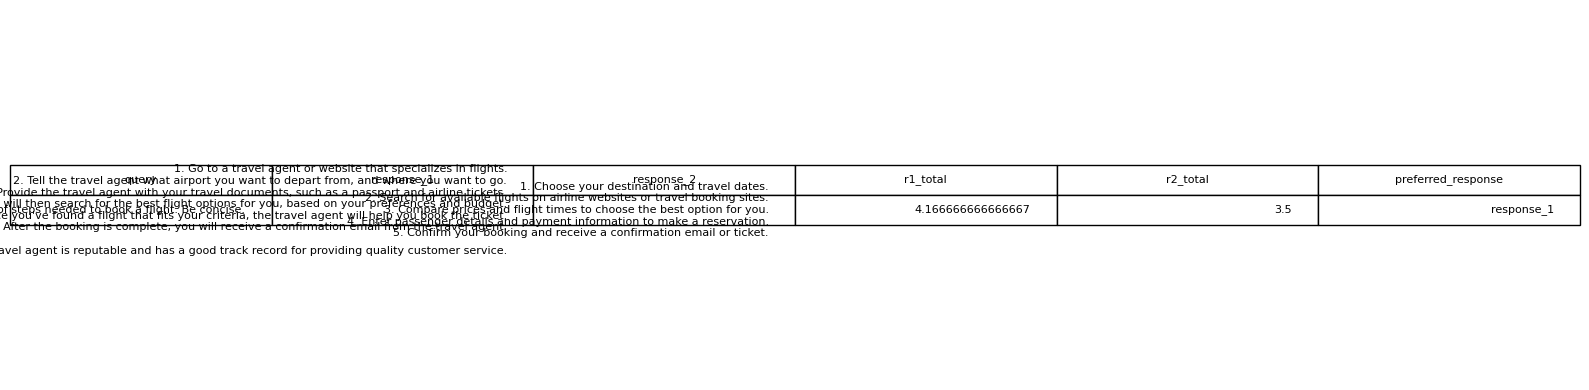

In [30]:
close_cases_display = close_cases[[
    "query", "response_1", "response_2", "r1_total", "r2_total", "preferred_response"
]].head(10)

close_cases_display.to_csv("pref_close_cases_examples.csv", index=False)

if close_cases_display.empty:
    print("No close/disagreement cases found with the current threshold. Increase the threshold and try again.")
else:
    fig, ax = plt.subplots(figsize=(16, 4))
    ax.axis('off')
    tbl = ax.table(
        cellText=close_cases_display.values,
        colLabels=close_cases_display.columns,
        loc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.5)
    plt.tight_layout()
    plt.savefig("pref_close_cases_examples_table.png", dpi=300, bbox_inches="tight")
    plt.show()

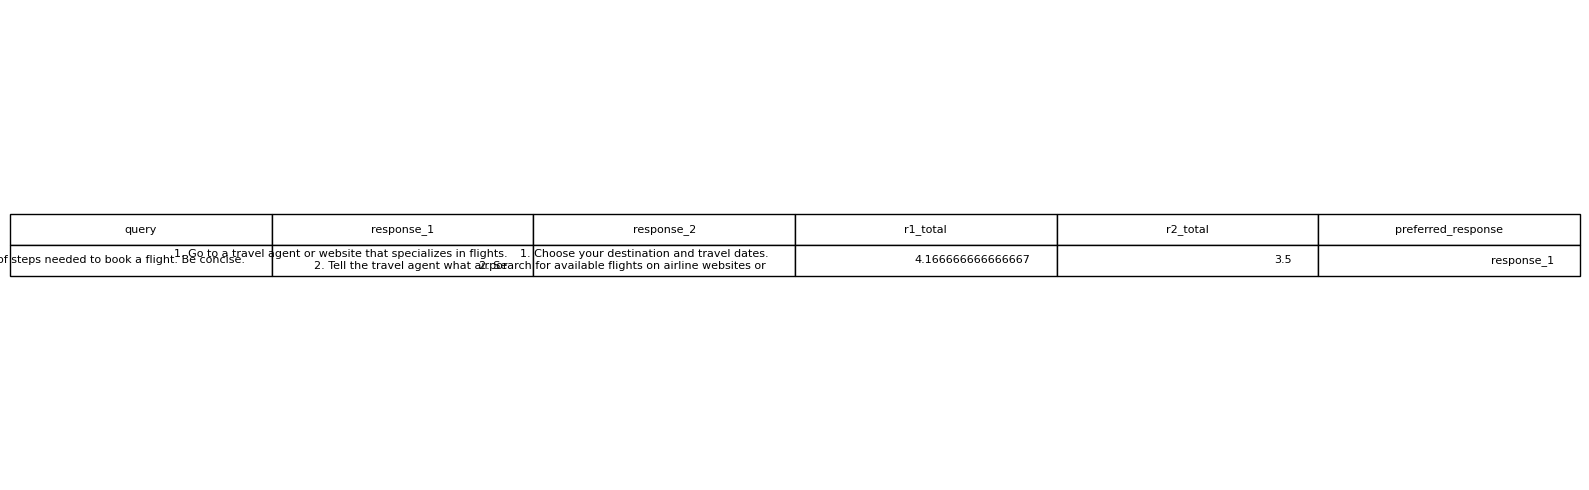

In [31]:
close_cases_display = close_cases[[
    "query", "response_1", "response_2", "r1_total", "r2_total", "preferred_response"
]].head(10).copy()

close_cases_display["query"] = close_cases_display["query"].str.slice(0, 80)
close_cases_display["response_1"] = close_cases_display["response_1"].str.slice(0, 100)
close_cases_display["response_2"] = close_cases_display["response_2"].str.slice(0, 100)

close_cases_display.to_csv("pref_close_cases_examples.csv", index=False)

fig, ax = plt.subplots(figsize=(16, 5))
ax.axis('off')
tbl = ax.table(
    cellText=close_cases_display.values,
    colLabels=close_cases_display.columns,
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.5)
plt.tight_layout()
plt.savefig("pref_close_cases_examples_table.png", dpi=300, bbox_inches="tight")
plt.show()